## Jogos Olímpicos e Paralímpicos de Verão: Análise Comparativa e Socioeconômica do Desempenho Global

### Integrantes:
- Élia Dutra Sena
- Luis Fernando de Araujo Oliveira
- Maria Eloisa Silva de Sousa
- Maria Clara Caldas Fernandes

--- 

### Introdução:

Nosso objetivo com esse projeto é realizar uma análise comparativa e socioeconômica do desempenho das nações nas Olimpíadas e Paralimpíadas de Verão.  
De um modo geral, buscamos identificar países com eficiência socioeconômica no esporte, investigar o que pode levar um país a ter alguma vantagem e analisar sua evolução ao longo do tempo.

### Dados Usados:

## Base de Dados:
- **Dados esportivos:**
  
  Histórico de medalhas por ano: país e suas respectivas medalhas recebidas da olimpíada do ano.
  
  Histórico de medalhas geral: país e a quantidade total de medalhas adquiridas em todas as olimpíadas.
  
  Atletas (Kaggle): dados gerais (nome, gênero, idade, peso, altura, time, esporte, cidade, medalha) sobre todos os atletas que participaram das olimpíadas entre 1896-2016.

  
- **Dados socioeconômicos:**
  
  PIB mundial.
  
  IDH mundial.

### Pré-processamento: 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler   
import scipy.stats as stats

##### Tratamento do CSV dos atletas:

Cria um dataframe que lê o arquivo com os dados dos atletas:

In [2]:
df = pd.read_csv('athlete_events.csv', encoding='ISO-8859-1')
display(df.head())

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


Organiza o arquivo tirando as linhas que tem atletas que competiram  em edições anteriores a de 1960 e nas olimpíadas de inverno e cria um novo CSV com os dados arrumados:

In [3]:
df_organizado = df[df['Year'] >= 1960].copy()
df_organizado = df_organizado[df_organizado["Season"] != "Winter"]

df_organizado.to_csv('athlete_events_limpo.csv', index=False, encoding='ISO-8859-1')
df_organizado.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
31,12,Jyri Tapani Aalto,M,31.0,172.0,70.0,Finland,FIN,2000 Summer,2000,Summer,Sydney,Badminton,Badminton Men's Singles,NaN
32,13,Minna Maarit Aalto,F,30.0,159.0,55.5,Finland,FIN,1996 Summer,1996,Summer,Atlanta,Sailing,Sailing Women's Windsurfer,NaN
33,13,Minna Maarit Aalto,F,34.0,159.0,55.5,Finland,FIN,2000 Summer,2000,Summer,Sydney,Sailing,Sailing Women's Windsurfer,NaN


##### Tratamento dos arquivos de medalhas das Paralimpíadas e Olimpíadas :

**Olimpíadas:**

Trata o nome dos países, pois estava diferente do que tem no PIB e dava erro ao tentar juntar os datasets.

    Como era: Brasil (BRA)
    Após o tratamento: fica uma coluna para o país que tem apenas o nome: Brasil e cria uma nova coluna que recebe o NOC: BRA.

Organizamos a posição dos países para que os que mais têm medalhas fiquem no topo.

Após tratar, cria um novo CSV.

In [4]:
df_olimpiadas = pd.read_csv('medalhas_olimpiadas_wikipedia.csv', encoding='utf-8')
display(df_olimpiadas.head())

,No.,País,Jogos,Ouro,Prata,Bronze,Total
0,1,USA Estados Unidos,29,1101,880,781,2762
1,2,URS União Soviética,9,395,319,296,1010
2,3,CHN China,12,302,227,197,726
3,4,GBR Grã-Bretanha,30,300,338,344,982
4,5,FRA França,30,240,280,298,818


In [5]:
df_olimpiadas = df_olimpiadas.sort_values(by='Total', ascending=False)
display(df_olimpiadas.head())


,No.,País,Jogos,Ouro,Prata,Bronze,Total
0,1,USA Estados Unidos,29,1101,880,781,2762
1,2,URS União Soviética,9,395,319,296,1010
3,4,GBR Grã-Bretanha,30,300,338,344,982
4,5,FRA França,30,240,280,298,818
2,3,CHN China,12,302,227,197,726


In [6]:
df_olimpiadas_limpo = df_olimpiadas['País'].str.extract(r'^([A-Z]{3})\s+(.*)')
df_olimpiadas_limpo.columns = ['NOC', 'País_Limpo']

df_olimpiadas['NOC'] = df_olimpiadas_limpo['NOC']
df_olimpiadas['País'] = df_olimpiadas_limpo['País_Limpo']

df_olimpiadas['País'] = df_olimpiadas['País'].str.replace(r'\[.*\]|\*', '', regex=True).str.strip()

display(df_olimpiadas.head())

,No.,País,Jogos,Ouro,Prata,Bronze,Total,NOC
0,1,Estados Unidos,29,1101,880,781,2762,USA
1,2,União Soviética,9,395,319,296,1010,URS
3,4,Grã-Bretanha,30,300,338,344,982,GBR
4,5,França,30,240,280,298,818,FRA
2,3,China,12,302,227,197,726,CHN


In [7]:
df_olimpiadas.to_csv('olimpiadas_medalhas_arrumado.csv', index=False, encoding='utf-8')

**Paralimpíadas:**

Trata o nome dos países, pois estava diferente do que tem no PIB e dava erro ao tentar juntar os datasets.

    Como era: Brasil (BRA)
    Após o tratamento: fica uma coluna para o país que tem apenas o nome: Brasil e cria uma nova coluna que recebe o NOC: BRA.

Além disso, Unifica as Alemanhas que tinham 3 versões diferentes, Alemanha (GER) [a], Alemanha Ocidental (FRG) [b], Alemanha Oriental (GDR) [c], somando suas medalhas.

Ordenamos o dataframe para que os maiores ganhadores de medalhas fiquem no topo.

Ao analisar dataframe nessa nova ordem percebemos que tinha uma linha que somava todas as outras medalhas juntas chamada "Totais", a tiramos para manter apenas países.

Após tratar, cria um novo CSV.

In [8]:
df_paraolimpiadas = pd.read_csv('medalhas_paralimpiadas_wikipedia.csv', encoding='utf-8')
display(df_paraolimpiadas.head())

,País,№,Ouro,Prata,Bronze,Total
0,África do Sul (RSA),11,121,95,88,304
1,Alemanha (GER) [a],8,199,266,253,718
2,Alemanha Ocidental (FRG) [b],8,322,260,246,828
3,Alemanha Oriental (GDR) [c],1,0,3,1,4
4,Angola (ANG),6,4,3,1,8


In [9]:
df_paraolimpiadas['NOC'] = df_paraolimpiadas['País'].str.extract(r'\((.*?)\)')

df_paraolimpiadas['País'] = df_paraolimpiadas['País'].str.replace(r'\s*\(.*', '', regex=True)
df_paraolimpiadas['País'] = df_paraolimpiadas['País'].str.replace(r'\[.*\]', '', regex=True).str.strip()
display(df_paraolimpiadas.head())

,País,№,Ouro,Prata,Bronze,Total,NOC
0,África do Sul,11,121,95,88,304,RSA
1,Alemanha,8,199,266,253,718,GER
2,Alemanha Ocidental,8,322,260,246,828,FRG
3,Alemanha Oriental,1,0,3,1,4,GDR
4,Angola,6,4,3,1,8,ANG


In [10]:
alemanhas = ['Alemanha Ocidental', 'Alemanha Oriental']
df_paraolimpiadas['País'] = df_paraolimpiadas['País'].replace(alemanhas, 'Alemanha')

df_paraolimpiadas = df_paraolimpiadas.groupby('País').agg({
    'Ouro': 'sum',
    'Prata': 'sum',
    'Bronze': 'sum',
    'Total': 'sum',
    'NOC': 'first' 
}).reset_index()

df_paraolimpiadas = df_paraolimpiadas.sort_values(by='Total', ascending=False)

display(df_paraolimpiadas.head())

,País,Ouro,Prata,Bronze,Total,NOC
115,Totais,7513,7298,7336,22147,NaN
40,Estados Unidos,808,736,739,2283,USA
48,Grã-Bretanha,667,621,626,1914,GBR
0,Alemanha,521,529,500,1550,GER
22,China,535,400,302,1237,CHN


In [11]:
df_paraolimpiadas = df_paraolimpiadas[df_paraolimpiadas['País'] != 'Totais']

display(df_paraolimpiadas.head())

,País,Ouro,Prata,Bronze,Total,NOC
40,Estados Unidos,808,736,739,2283,USA
48,Grã-Bretanha,667,621,626,1914,GBR
0,Alemanha,521,529,500,1550,GER
22,China,535,400,302,1237,CHN
6,Austrália,389,422,394,1205,AUS


In [12]:
df_paraolimpiadas.to_csv('paralimpiada_medalhas_arrumado.csv', index=False, encoding='utf-8')

### Perguntas:

#### 1 - O "Efeito Casa" 

​**A Pergunta:** O país sede realmente ganha mais medalhas quando sedia o evento?  

​Comparação: Analisar o desempenho dos países sedes na olimpíada anterior, na que sediaram e na posterior.  


#### 2 - Representatividade Feminina  
**A ​Pergunta:** Como a participação das mulheres evoluiu ao longo das décadas? Existem esportes que ainda são muito desiguais?  

​Comparação: Duas linhas do tempo (1960–2024). Uma mostrando a % de mulheres nas Olimpíadas e outra nas Paralimpíadas.  
​Análise: As Paralimpíadas começaram depois, mas será que evoluíram mais rápido na inclusão feminina?



#### 3 - Monopólios Esportivos
**​A Pergunta:** Quais esportes são dominados por um único país?  

​Comparação: Analisar a porcentagem de medalhas de ouro ganhas por um único país em modalidades específicas.  
​Ex: Tênis de Mesa (China), Basquete Masculino (EUA), Corridas de Longa Distância (Quênia/Etiópia), Tiro com Arco (Coreia do Sul).


#### 4 - Eficiência por PIB
​**A Pergunta:** O dinheiro "compra" mais medalhas em qual dos dois eventos?  

​Comparação: Cruzar o PIB dos países com o quadro de medalhas de ambos os eventos.  
​Hipótese: Equipamentos paralímpicos (cadeiras de rodas de titânio, próteses de fibra de carbono) são caríssimos. A correlação entre PIB e vitória é mais forte nas Paralimpíadas do que nas Olimpíadas


#### 5 - A "Correlação de Potência" (O Espelho Distorcido)  

**​A Pergunta:** Os países que dominam as Olimpíadas são os mesmos que dominam as Paralimpíadas?  

Comparação: O quanto é possível correlacionar o desempenho nas Olimpíadas com o desempenho nas Paralimpíadas? O número de medalhas segue numa mesma proporção?  
Análise: Gráficos de barra comparativos e um gráfico de dispersão (Scatter Plot) onde o eixo X são medalhas Olímpicas e o eixo Y são medalhas Paralímpicas.


- Para analisar essa relação, lemos os CSVs referentes ao quadro de medalhas geral de ambos os eventos e consertamos uma inconsistência encontrada na coluna "Total" (total de medalhas) do dataset paralímpico.  
- Criamos um novo dataframe mesclando os anteriores com dados de total de medalhas de cada evento e também no geral.

In [15]:
# Leitura dos dados
df_olimpiadas = pd.read_csv('olimpiadas_medalhas_arrumado.csv', encoding='utf-8')
df_paralimpiadas = pd.read_csv('paralimpiada_medalhas_arrumado.csv', encoding='utf-8')

# Resolve inconsistências
df_paralimpiadas["Total_calc"] = df_paralimpiadas['Ouro'] + df_paralimpiadas['Prata'] + df_paralimpiadas['Bronze']
df_paralimpiadas["Total"] = df_paralimpiadas["Total_calc"]

display(df_olimpiadas.head())
display(df_paralimpiadas.head())

# Cria dataframe combinado
df_olimpico_total = df_olimpiadas.sort_values(by= "Total", ascending= False)
df_olimpico_total = df_olimpico_total[['País', 'Total']]
df_olimpico_total = df_olimpico_total.rename(columns={"Total": "Total_Olimpico"})

df_paralimpico_total = df_paralimpiadas.sort_values(by= "Total", ascending= False)
df_paralimpico_total = df_paralimpico_total[['País', 'Total']]
df_paralimpico_total = df_paralimpico_total.rename(columns={"Total": "Total_Paralimpico"})

df_olim_e_para = pd.merge(df_olimpico_total, df_paralimpico_total, on='País', how='outer')
df_olim_e_para["Total_Combinado"] = df_olim_e_para["Total_Olimpico"] + df_olim_e_para["Total_Paralimpico"]
df_olim_e_para = df_olim_e_para[df_olim_e_para["Total_Combinado"] > 0]

display(df_olim_e_para.head())

,No.,País,Jogos,Ouro,Prata,Bronze,Total,NOC
0,1,Estados Unidos,29,1101,880,781,2762,USA
1,2,União Soviética,9,395,319,296,1010,URS
2,4,Grã-Bretanha,30,300,338,344,982,GBR
3,5,França,30,240,280,298,818,FRA
4,3,China,12,302,227,197,726,CHN


,País,Ouro,Prata,Bronze,Total,NOC,Total_calc
0,Estados Unidos,808,736,739,2283,USA,2283
1,Grã-Bretanha,667,621,626,1914,GBR,1914
2,Alemanha,521,529,500,1550,GER,1550
3,China,535,400,302,1237,CHN,1237
4,Austrália,389,422,394,1205,AUS,1205


,País,Total_Olimpico,Total_Paralimpico,Total_Combinado
1,Alemanha,685.0,1550.0,2235.0
6,Argentina,77.0,166.0,243.0
7,Argélia,17.0,85.0,102.0
9,Arábia Saudita,4.0,5.0,9.0
13,Austrália,596.0,1205.0,1801.0


- Seguimos com as análises:

C:\Users\ednal\AppData\Local\Temp\ipykernel_18236\1151692400.py:5: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df_top_olim, x='País', y='Total', hue= "País", palette=["#0c7ed0"], legend= False)


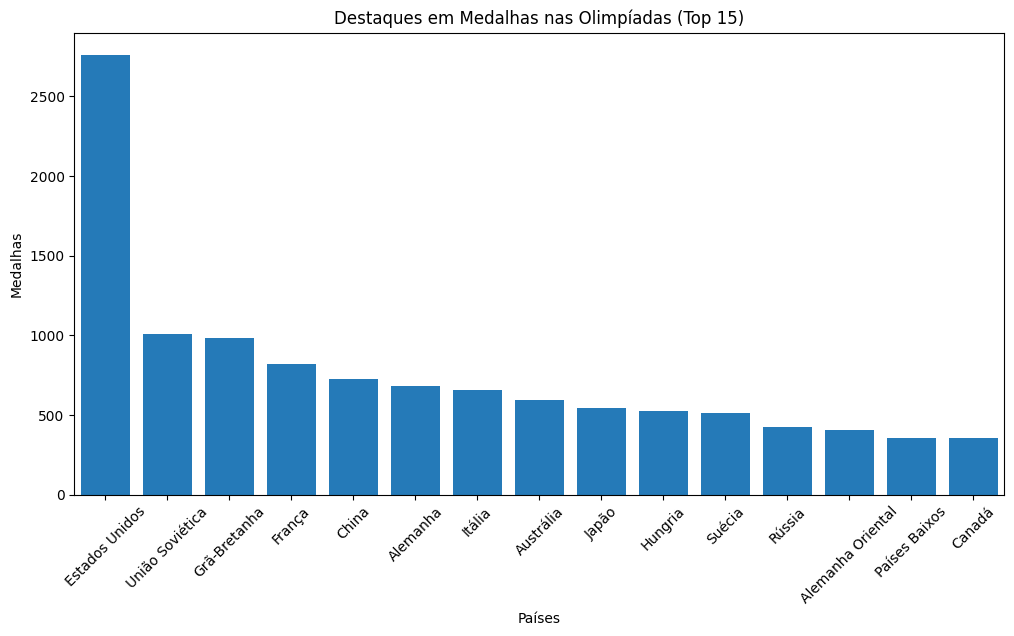

In [16]:
def potencias_olimpicas():
    df_top_olim = df_olimpiadas.nlargest(15, "Total")

    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_top_olim, x='País', y='Total', hue= "País", palette=["#0c7ed0"], legend= False)
    plt.xlabel("Países")
    plt.ylabel("Medalhas")
    plt.xticks(rotation=45)
    plt.title('Destaques em Medalhas nas Olimpíadas (Top 15)')
    plt.show()

potencias_olimpicas()

C:\Users\ednal\AppData\Local\Temp\ipykernel_18236\1449674887.py:5: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df_top_para, x='País', y='Total', hue= "País", palette=["#8ED1EB"], legend= False)


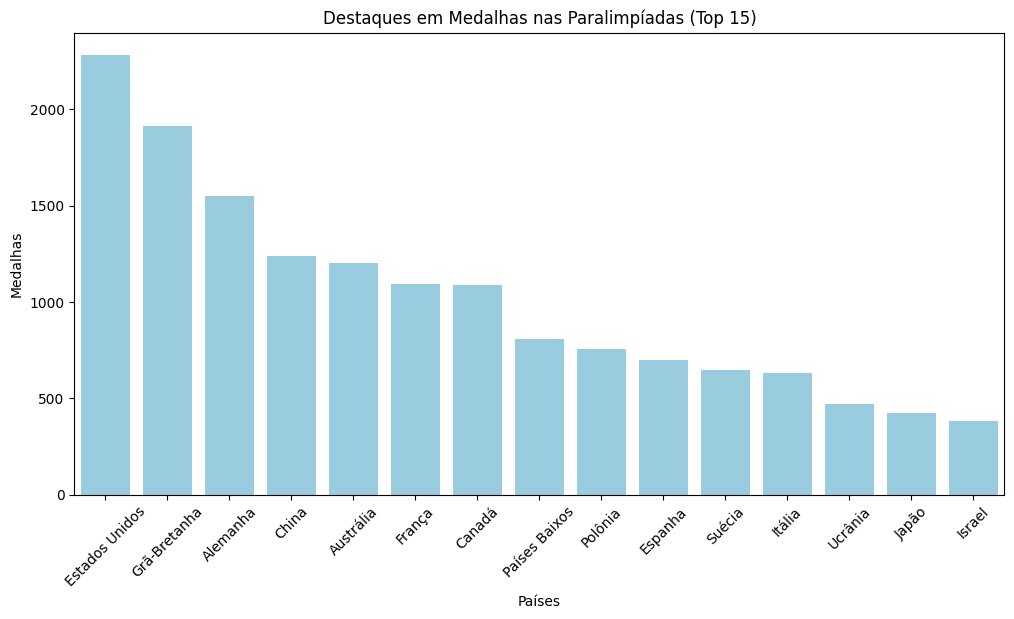

In [17]:
def potencias_paralimpicas():
    df_top_para = df_paralimpiadas.nlargest(15, "Total")

    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_top_para, x='País', y='Total', hue= "País", palette=["#8ED1EB"], legend= False)
    plt.xlabel("Países")
    plt.ylabel("Medalhas")
    plt.xticks(rotation=45)
    plt.title('Destaques em Medalhas nas Paralimpíadas (Top 15)')
    plt.show()

potencias_paralimpicas()

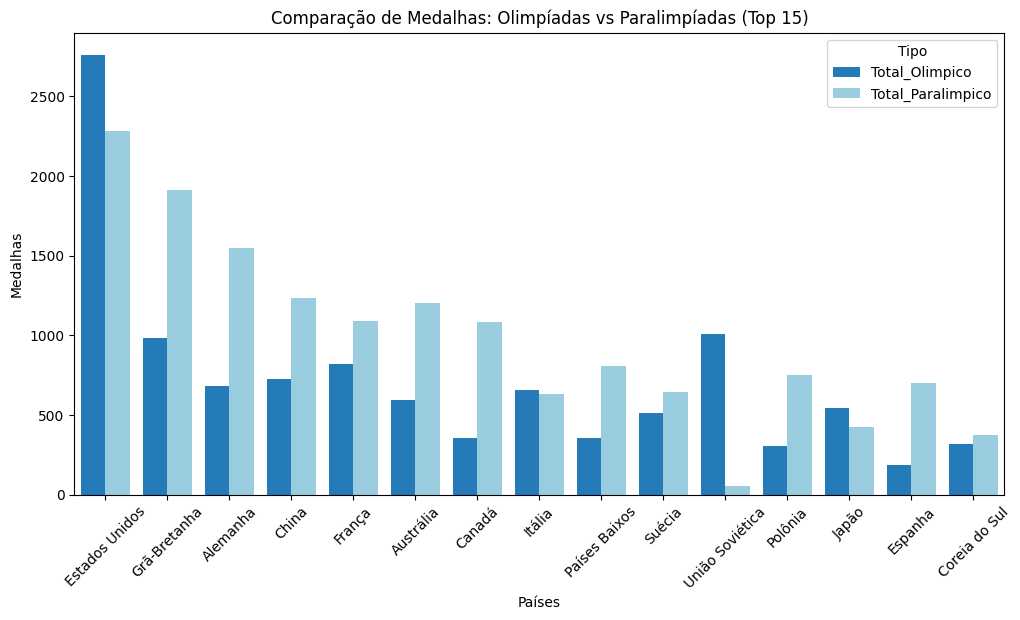

In [18]:
def compara_potencias():
    df_top = df_olim_e_para.nlargest(15, "Total_Combinado")
    df_plot = df_top.melt(id_vars='País', value_vars=['Total_Olimpico', 'Total_Paralimpico'], var_name='Tipo', value_name='Medalhas')

    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_plot, x='País', y='Medalhas', hue='Tipo',  palette=["#0c7ed0", "#8ED1EB"])
    plt.xlabel("Países")
    plt.ylabel("Medalhas")
    plt.xticks(rotation=45)
    plt.title('Comparação de Medalhas: Olimpíadas vs Paralimpíadas (Top 15)')
    plt.show()

compara_potencias()

In [19]:
df_olim_e_para[["Total_Olimpico", "Total_Paralimpico", "Total_Combinado"]].corr() # É uma correlação positiva e bem forte

,Total_Olimpico,Total_Paralimpico,Total_Combinado
Total_Olimpico,1.000000,0.822738,0.946105
Total_Paralimpico,0.822738,1.000000,0.962486
Total_Combinado,0.946105,0.962486,1.000000


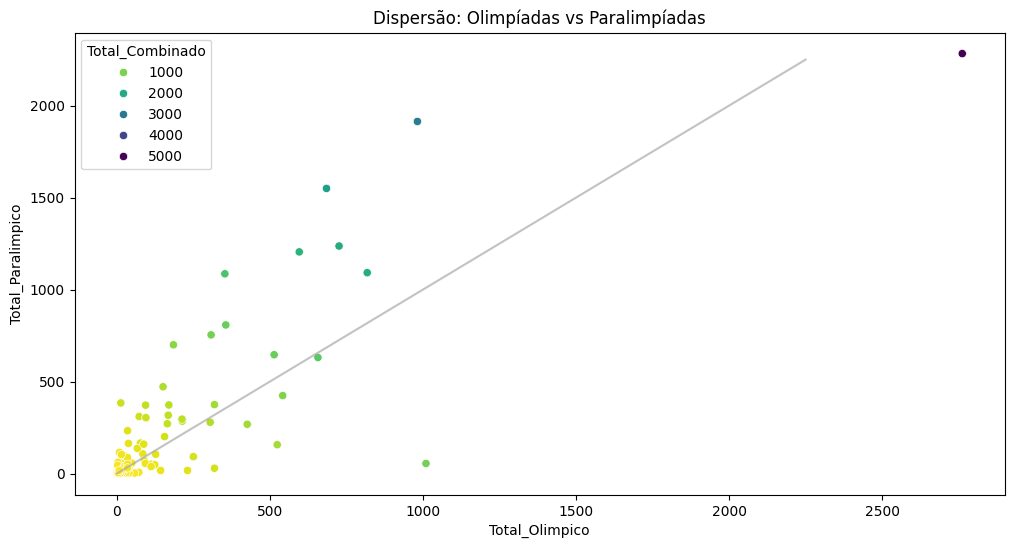

In [20]:
def plot_line_scale1():

    plt.figure(figsize=(12, 6))
    xpoints = np.array([0, 2250])
    ypoints = np.array([0, 2250])
    plt.plot(xpoints, ypoints, c= "#A9A9A9", alpha= 0.7)
    sns.scatterplot(data= df_olim_e_para, x= "Total_Olimpico", y= "Total_Paralimpico", hue= "Total_Combinado", palette= "viridis_r")
    plt.title('Dispersão: Olimpíadas vs Paralimpíadas')
    plt.show()

plot_line_scale1()

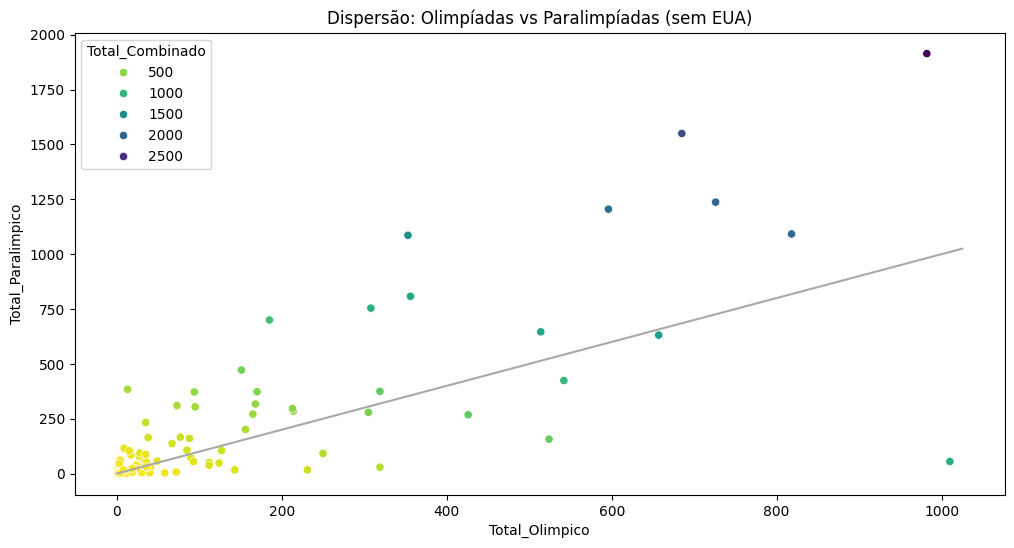

In [21]:
def plot_line_scale2():
    df_sem_eua = df_olim_e_para[df_olim_e_para["País"] != "Estados Unidos"]

    plt.figure(figsize=(12, 6))
    xpoints = np.array([0, 1025])
    ypoints = np.array([0, 1025])
    plt.plot(xpoints, ypoints, c= "#A9A9A9")
    sns.scatterplot(data= df_sem_eua, x= "Total_Olimpico", y= "Total_Paralimpico", hue= "Total_Combinado", palette= "viridis_r")
    plt.title('Dispersão: Olimpíadas vs Paralimpíadas (sem EUA)')
    plt.show()

plot_line_scale2()

**Conclusão:**
De um modo geral, sim. Ao analisar os países que mais se destacam em cada um dos eventos, a maioria dos nomes se repete, sendo estes também os que apresentam melhor desempenho geral. As correlações positivas e os gráficos também nos mostram que em geral, o número de medalhas em cada evento cresce junto.  
Porém, ao comparar em números esse desempenho, é interessante observar que a maioria desses países (e também grande parte dos demais) possui melhores resultados nas Paralimpíadas, a exemplo do próprio Brasil. É como se as medalhas Paralímpicas elevassem a média geral desses países.    
Ao pesquisar mais sobre o tema, vimos que a estrutura das Paralimpíadas quanto à divisão das provas em categorias funcionais (depende da deficiência) abre mais espaço para atletas multi-medalhistas. Além disso, alguns países realmente investem mais nas Paralimpíadas, e isso tudo contribui para os resultados que vemos.

### Conclusão:

// Resumir os resultados encontrados e explicar por que são importantes. Apontar limitações, trabalhos futuros e melhorias que podem ser feitas.

OBS: Pelo menos três tipos diferentes de gráficos devem ser usados no relatório.